# **FinTrust Data Exploration & Visualization**
This notebook performs exploratory data analysis (EDA) on FinTrust's customer and transaction datasets by inspecting structure, checking for missing values, duplicates, and validating data integrity and developing visuals as a foundation for deeper financial and behavioral analysis.

 **Import Libraries & Load Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

In [3]:
Customer = "FinTrust_CustomerData.csv"

In [4]:
Transaction = "FinTrust_TransactionData.csv"

In [5]:
Customer = pd.read_csv(Customer)
Customer.head()

,Customer_ID,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-C00001,Ibrahim Adeyemi,56,Male,Lagos,Premium,Savings,55,84.9,500k-999k,Mobile App,Active
1,FT-C00002,Yusuf Mohammed,46,Male,Kano,Everyday,Current,79,50.7,500k-999k,Mobile App,Active
2,FT-C00003,Emeka Adeyemi,32,Female,Port Harcourt,Everyday,Savings,43,56.1,1m+,Mobile App,Active
3,FT-C00004,David Williams,60,Female,Benin City,Premium,Premium,44,54.0,500k-999k,Mobile App,Dormant
4,FT-C00005,Blessing Adeyemi,25,Male,Kaduna,Premium,Savings,68,85.1,500k-999k,Mobile App,Active


In [6]:
Transaction = pd.read_csv(Transaction)
Transaction.head()

,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag
0,FT-T000001,FT-C01135,1/1/2026 0:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes
1,FT-T000002,FT-C00428,1/1/2026 0:10,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes
2,FT-T000003,FT-C00469,1/1/2026 0:21,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No
3,FT-T000004,FT-C01015,1/1/2026 0:32,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No
4,FT-T000005,FT-C00870,1/1/2026 0:43,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No


**Initial Inspection**

In [7]:
Customer.shape
Customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               1500 non-null   object 
 1   Customer_Name             1500 non-null   object 
 2   Age                       1500 non-null   int64  
 3   Gender                    1500 non-null   object 
 4   City                      1500 non-null   object 
 5   Customer_Segment          1500 non-null   object 
 6   Account_Type              1500 non-null   object 
 7   Tenure_Months             1500 non-null   int64  
 8   Digital_Engagement_Score  1500 non-null   float64
 9   Monthly_Income_Band       1500 non-null   object 
 10  Preferred_Channel         1500 non-null   object 
 11  Account_Status            1500 non-null   object 
dtypes: float64(1), int64(2), object(9)
memory usage: 140.8+ KB


In [8]:
Transaction.shape
Transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Transaction_ID             12000 non-null  object 
 1   Customer_ID                12000 non-null  object 
 2   Transaction_DateTime       12000 non-null  object 
 3   Transaction_Type           12000 non-null  object 
 4   Amount_NGN                 12000 non-null  float64
 5   Channel                    12000 non-null  object 
 6   Device_Type                11904 non-null  object 
 7   Location                   11904 non-null  object 
 8   International_Transaction  12000 non-null  object 
 9   Transaction_Status         12000 non-null  object 
 10  Risk_Review_Flag           12000 non-null  object 
dtypes: float64(1), object(10)
memory usage: 1.0+ MB


**Missing Values**

In [9]:
Customer.isnull().sum()

Customer_ID                 0
Customer_Name               0
Age                         0
Gender                      0
City                        0
Customer_Segment            0
Account_Type                0
Tenure_Months               0
Digital_Engagement_Score    0
Monthly_Income_Band         0
Preferred_Channel           0
Account_Status              0
dtype: int64

In [10]:
Transaction.isnull().sum()

Transaction_ID                0
Customer_ID                   0
Transaction_DateTime          0
Transaction_Type              0
Amount_NGN                    0
Channel                       0
Device_Type                  96
Location                     96
International_Transaction     0
Transaction_Status            0
Risk_Review_Flag              0
dtype: int64

**Duplicates**

In [11]:
Customer.duplicated().sum()

np.int64(0)

In [12]:
Transaction.duplicated().sum()

np.int64(0)

**Data types**

In [13]:
Customer.dtypes

Customer_ID                  object
Customer_Name                object
Age                           int64
Gender                       object
City                         object
Customer_Segment             object
Account_Type                 object
Tenure_Months                 int64
Digital_Engagement_Score    float64
Monthly_Income_Band          object
Preferred_Channel            object
Account_Status               object
dtype: object

In [14]:
Transaction.dtypes

Transaction_ID                object
Customer_ID                   object
Transaction_DateTime          object
Transaction_Type              object
Amount_NGN                   float64
Channel                       object
Device_Type                   object
Location                      object
International_Transaction     object
Transaction_Status            object
Risk_Review_Flag              object
dtype: object

**Basic statistics**

In [15]:
Customer.describe()

,Age,Tenure_Months,Digital_Engagement_Score
count,1500.000000,1500.000000,1500.000000
mean,41.587333,49.858667,67.954000
std,13.733127,27.910990,17.555376
min,18.000000,1.000000,16.700000
25%,29.750000,26.000000,56.100000
50%,42.000000,51.000000,68.000000
75%,53.000000,74.000000,80.925000
max,65.000000,96.000000,100.000000


In [16]:
Transaction.describe()

,Amount_NGN
count,12000.000000
mean,46706.446238
std,86028.715234
min,100.170000
25%,2192.220000
50%,10305.935000
75%,48484.475000
max,693454.450000


**Merge Datasets for Combined Analysis**

In [17]:
df = Transaction.merge(Customer,
on='Customer_ID', how='left')

df.shape 

(12000, 22)

In [18]:
df.isnull().sum().sum()

np.int64(192)

# **Visualizations and Interpretations**

**Visualization 1: Transactions by Status**

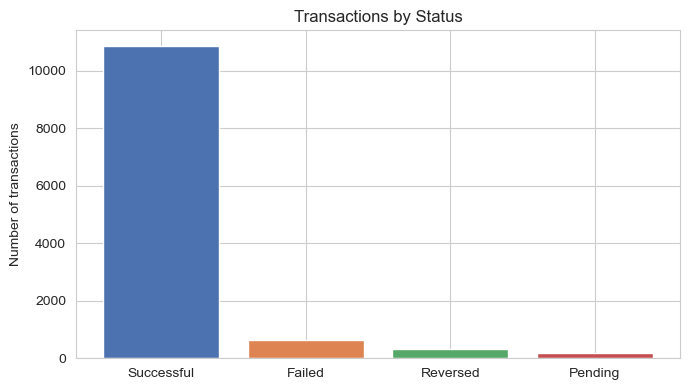

Transaction_Status
Successful    90.47
Failed         5.25
Reversed       2.72
Pending        1.57
Name: count, dtype: float64


In [19]:
status = Transaction["Transaction_Status"].value_counts()
share = (status / status.sum()*100).round(2)
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(status.index, status.values, color=sns.color_palette("deep") [:4])
ax.set(title="Transactions by Status", ylabel="Number of transactions")
plt.tight_layout(); plt.show()
print(share)

**What it shows:** 90.47% of transactions are successful, 5.25% Failed, 2.72% Reversed and 1.57% Pending

**Why it matters:** The success rate is the headline health measure of a digital bank, and every non-successful transaction is a potential customer_suppert contact.

**Business Insight:** The 9.5% of failed/reversed/pending transactions is the real workload for the support teams to reduce.

**Visualization 2: Preffered Channel by Customers**

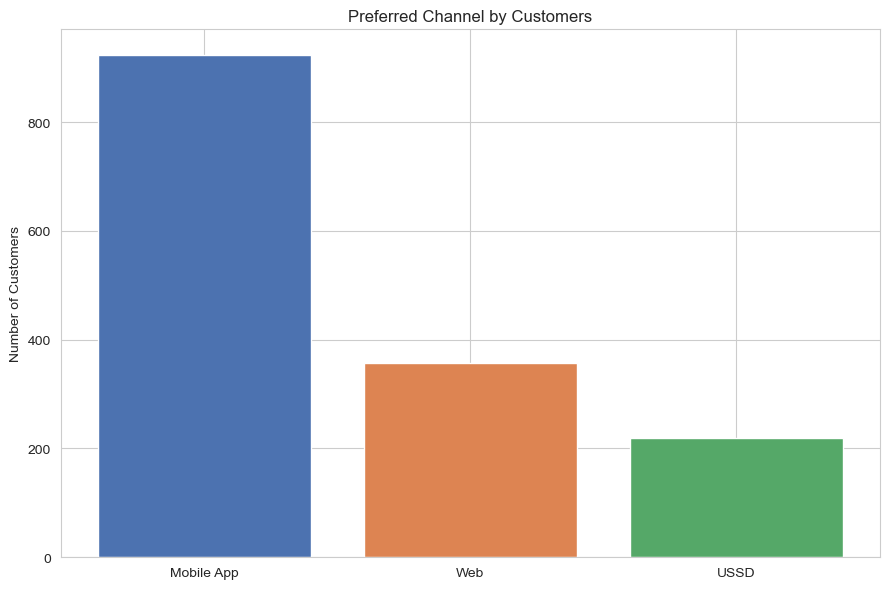

Preferred_Channel
Mobile App    61.6
Web           23.8
USSD          14.6
Name: count, dtype: float64


In [20]:
channel = Customer["Preferred_Channel"].value_counts()
share = (channel/channel.sum()*100).round(2)
fig, ax = plt.subplots(figsize=(9,6))
bars = ax.bar(channel.index, channel.values, color=sns.color_palette("deep") [:3])
ax.set(title="Preferred Channel by Customers", ylabel="Number of Customers")
plt.tight_layout(); plt.show()
print(share)

**What it shows:** The most number of customers(61.6%) prefer using Mobile App, followed by Web (23.8%) and USSD (14.6%).

**Why it matters:** It tells FinTrust where customers expected to be  served.

**Business Insight:** FinTrust should consider investing a lot in Mobile App by making it more reliable and add more features, since its what most customers chose for most of their transactions.

**Visualization 3: Successful Value by Transaction Type**

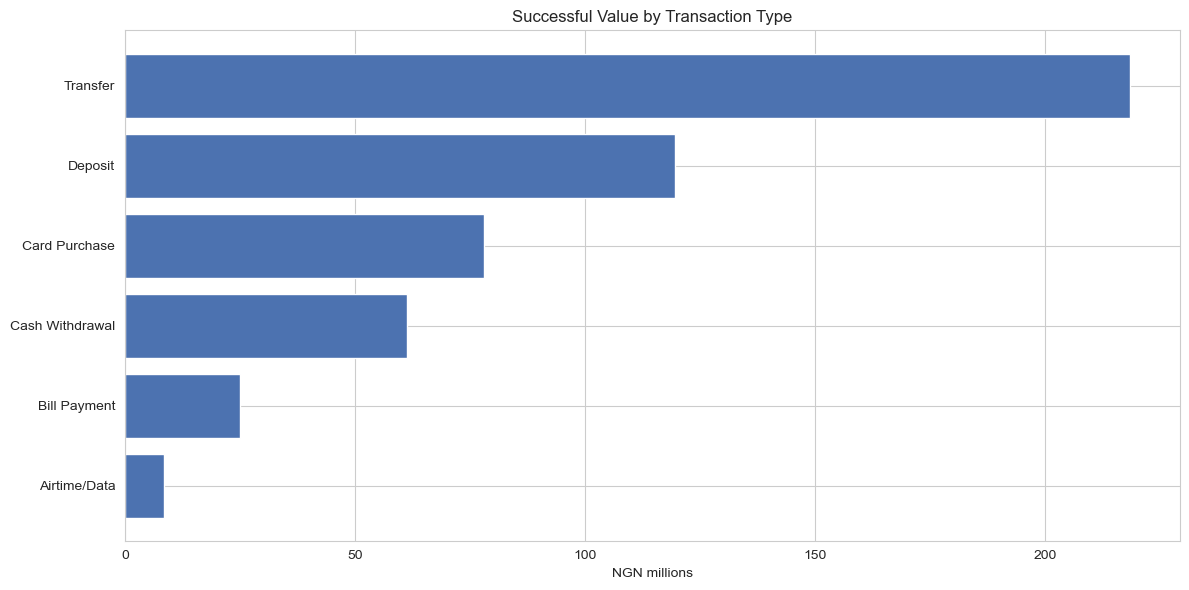

Transaction_Type
Airtime/Data         9.0
Bill Payment        25.0
Cash Withdrawal     61.0
Card Purchase       78.0
Deposit            120.0
Transfer           218.0
Name: Amount_NGN, dtype: float64


In [21]:
by_type = (Transaction[Transaction["Transaction_Status"]=="Successful"].groupby("Transaction_Type")["Amount_NGN"].sum() / 1e6).sort_values()
fig, ax = plt.subplots()
ax.barh(by_type.index, by_type.values, color=sns.color_palette("deep")[0])
ax.set(title="Successful Value by Transaction Type", xlabel="NGN millions")
plt.tight_layout(); plt.show()
print(by_type.round(0))


**What it shows:** Transfer generated the most money(NGN218M), followed by Deposit(NGN120M); Airtime/Data is the smallest (NGN9M) 

**Why it matters:** It shows which products actually drives FinTrust's transaction value.

**Business Insight:** Looking at this, Transfers are the core product customers mostly subscribe to. FinTrust must keep this product more rliable and faster for customer so that it can brings in more value into the company.

**Visualization 4: Distribution of Transaction Amount**

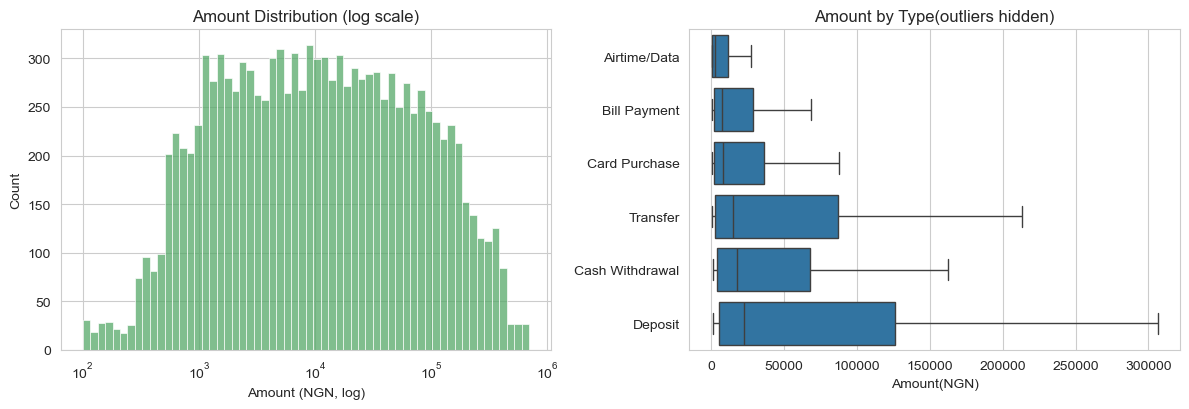

Mean 46,706 | Median 10,306 | Skewness 3.20
IQR upper bound 117,923 | Outliers 1,474 (12.3%) | Max 693,454


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.2))
sns.histplot(Transaction["Amount_NGN"], bins=60, log_scale=True, ax=axes[0], color=sns.color_palette("deep")[2])
axes[0].set(title="Amount Distribution (log scale)", xlabel="Amount (NGN, log)")
order = Transaction.groupby("Transaction_Type") ["Amount_NGN"].median().sort_values().index
sns.boxplot(data=Transaction, y="Transaction_Type", x="Amount_NGN", order=order, showfliers=False, ax=axes[1])
axes[1].set(title="Amount by Type(outliers hidden)", xlabel="Amount(NGN)", ylabel="")
plt.tight_layout(); plt.show()

a = Transaction["Amount_NGN"]
q1, q3 = a.quantile([.25,.75]); upper = q3 + 1.5*(q3-q1)
print(f"Mean {a.mean():,.0f} | Median {a.median():,.0f} | Skewness {a.skew():,.2f}")
print(f"IQR upper bound {upper:,.0f} | Outliers {(a>upper).sum():,} ({(a>upper).mean():,.1%}) | Max {a.max():,.0f}")

**Visualization 5: Failure Rate by Channel**

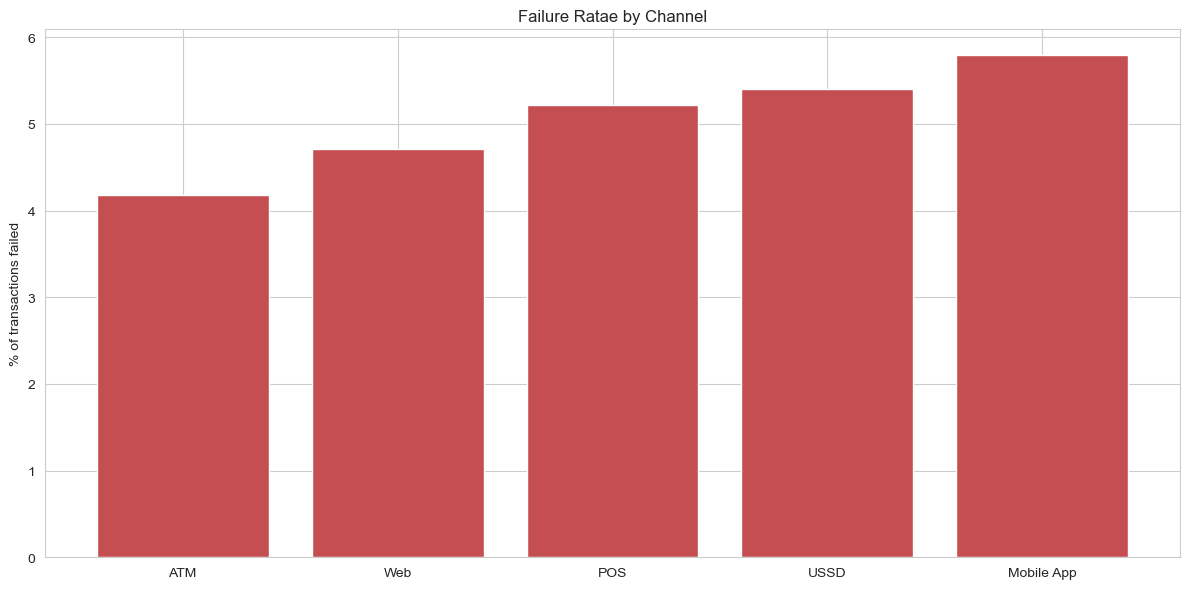

Channel
ATM           4.18
Web           4.71
POS           5.22
USSD          5.40
Mobile App    5.80
Name: Transaction_Status, dtype: float64


In [23]:
fail = (Transaction["Transaction_Status"] == "Failed").groupby(Transaction["Channel"]).mean().mul(100).round(2).sort_values()
fig, ax = plt.subplots()
ax.bar(fail.index, fail.values, color=sns.color_palette("deep")[3])
ax.set(title="Failure Ratae by Channel", ylabel="% of transactions failed")
plt.tight_layout()
plt.show()
print(fail)

**What it shows:** Mobile App has the highest failure rate (5.80%); ATM has the lowest (4.18%).

**Why it matters:** Since Mobile App is the biggest channel used, its failures affect the most Customers.

**Business Insight:** Fixing Mobile App reliability would remove the most failed transactions overall.

**Visualization 6: Risk-Review Rate by Transaction Type**

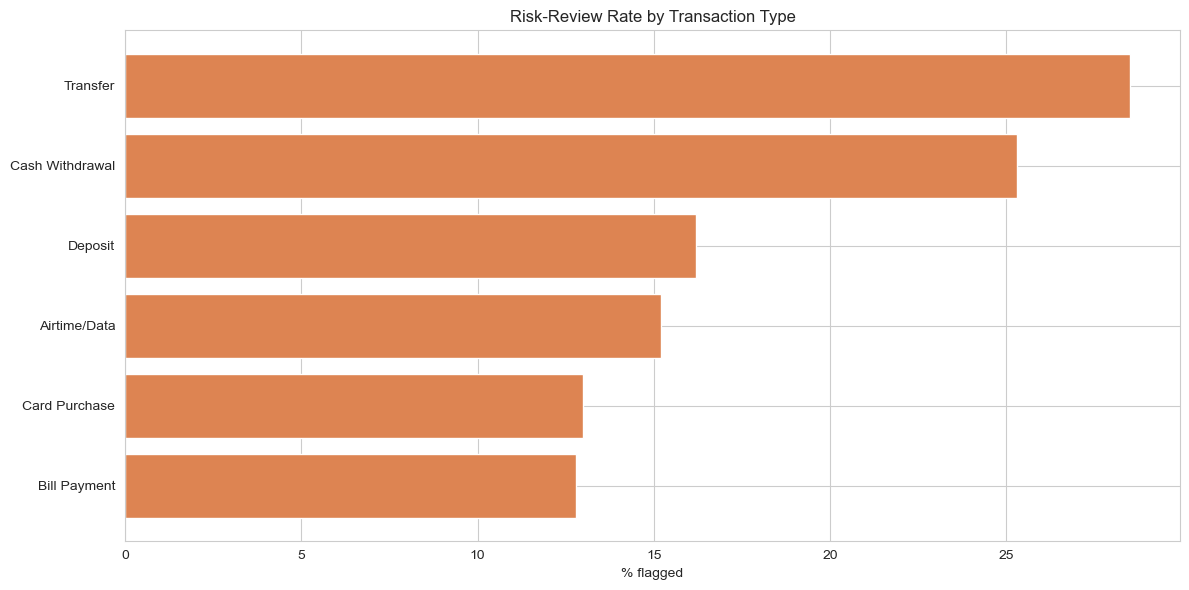

Transaction_Type
Bill Payment       12.8
Card Purchase      13.0
Airtime/Data       15.2
Deposit            16.2
Cash Withdrawal    25.3
Transfer           28.5
Name: Risk_Review_Flag, dtype: float64


In [24]:
risk = (Transaction["Risk_Review_Flag"] == "Yes").groupby(Transaction["Transaction_Type"]).mean().mul(100).round(1).sort_values()
fig, ax = plt.subplots()
ax.barh(risk.index, risk.values, color=sns.color_palette("deep")[1])
ax.set(title="Risk-Review Rate by Transaction Type", xlabel="% flagged")
plt.tight_layout()
plt.show()
print(risk)

**What it shows:** Transfers(28.5%) and Cash Withdrawals(25.3%) are flagged for review far more than Bill payments(12.8%).

**Why it matters:** It shows where review term spend their time most.

**Business Insight:** Review effort is concentrated on transactions where money actually leaves the account. This is a sensible pattern, not a flaw.

**Visualization 7: Customer Value Concerntration**

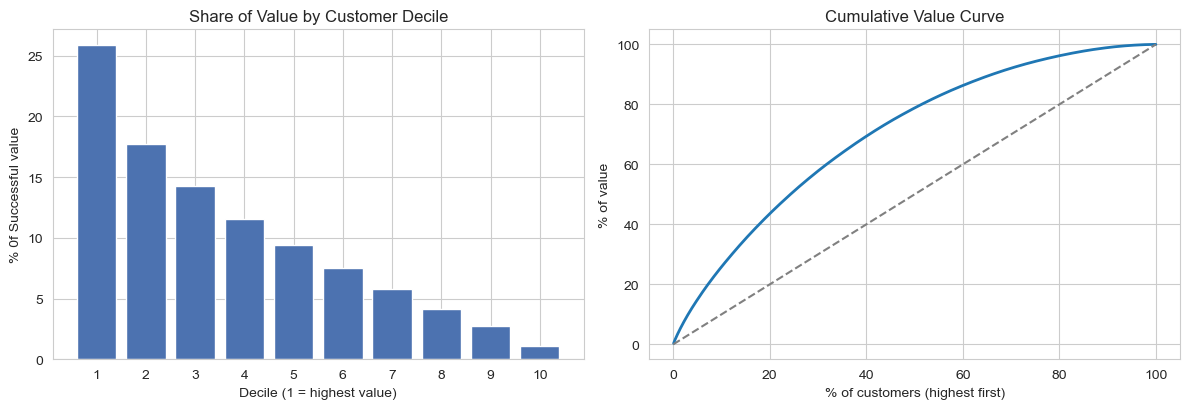

{1: 25.86, 2: 17.71, 3: 14.24, 4: 11.57, 5: 9.43, 6: 7.49, 7: 5.77, 8: 4.15, 9: 2.72, 10: 1.06}
Top 10%: 25.9% | Top 30%: 57.8% | Bottom 50%: 21.2%


In [25]:
cust_val = Transaction.groupby("Customer_ID") ["Amount_NGN"].sum().sort_values(ascending=False)
decile = pd.qcut(cust_val.rank(method="first", ascending=False), 10, labels=range(1, 11))
share = cust_val.groupby(decile, observed=True).sum()/ cust_val.sum()*100
fig, axes = plt.subplots(1, 2, figsize=(12,4.2))
axes[0].bar(share.index.astype(str), share.values, color=sns.color_palette("deep")[0])
axes[0].set(title="Share of Value by Customer Decile", xlabel="Decile (1 = highest value)", ylabel="% 0f Successful value")
cum = np.cumsum(cust_val.values) / cust_val.sum() * 100
axes[1].plot(np.arange(1, len(cum)+1)/len(cum)*100, cum, lw=2)
axes[1].plot([0,100],[0,100], ls="--", color="grey")
axes[1].set(title="Cumulative Value Curve", xlabel="% of customers (highest first)", ylabel="% of value")
plt.tight_layout(); plt.show()
print(share.round(2).to_dict())
print("Top 10%%: %.1f%% | Top 30%%: %.1f%% | Bottom 50%%: %.1f%%" % (share.iloc[0], share.iloc[:3].sum(), share.iloc[5:].sum()))

**What it shows:** The Top 10% of customers generate 25.9% of all value; the Bottom 50% generate only 21.2%.

**Why it matters:** Value is unevenly spread across customers.

**Business Insight:** The top customers decile deserves the most retention attention, since losing them would hurt revenue the most.

**Transaction and Customer Data Validating**

In [26]:
Transaction["Transaction_DateTime"] = pd.to_datetime(Transaction["Transaction_DateTime"])
Transaction["Month"] = Transaction["Transaction_DateTime"].dt.to_period("M")
Transaction["IsSuccess"] = (Transaction["Transaction_Status"] == "Successful").astype(int)
Transaction["IsFlag"] = (Transaction["Risk_Review_Flag"] == "Yes").astype(int)

print(Transaction.shape, Customer.shape)

(12000, 14) (1500, 12)


**Customer-level model (rebuilt from the transaction log)**

In [27]:
cust_model = Transaction.groupby("Customer_ID").agg(
    Txn_Count=("Transaction_ID", "count"),
    Success_Count=("IsSuccess", "sum"),
    Value_Success=("Amount_NGN", lambda x: x[Transaction.loc[x.index, "IsSuccess"] == 1].sum()),
    Flag_Count=("IsFlag", "sum"),
    Last_Txn=("Transaction_DateTime", "max")
).reset_index()

cust_model["Success_Rate"] = cust_model["Success_Count"]/ cust_model["Txn_Count"]
cust_model = cust_model.merge(Customer[["Customer_ID", "Customer_Segment"]], on="Customer_ID")
cust_model.head()

,Customer_ID,Txn_Count,Success_Count,Value_Success,Flag_Count,Last_Txn,Success_Rate,Customer_Segment
0,FT-C00001,7,7,389228.44,1,2026-03-29 16:22:00,1.000000,Premium
1,FT-C00002,5,4,261751.92,0,2026-02-28 14:49:00,0.800000,Everyday
2,FT-C00003,2,2,30819.66,0,2026-02-23 17:48:00,1.000000,Everyday
3,FT-C00004,9,8,114303.44,3,2026-03-30 05:52:00,0.888889,Premium
4,FT-C00005,7,6,277560.44,2,2026-03-29 12:46:00,0.857143,Premium


**What it shows:** A 1,500-row pandas DataFrame, one row per customer, mirroring the Excel Cust_Model (transaction count, success count, successful value, flag count, last transaction date, and success rate).


**Business Insight:** Having this model in Python independently of Excel means the customer-level findings below aren't dependent on one tool's formulas — they're reproducible from the raw data in a second, completely separate calculation engine.

In [29]:
as_of_date = cust_model["Last_Txn"].max() + pd.Timedelta(days=1) 
cust_model["Recency_Days"] = (as_of_date - cust_model["Last_Txn"]).dt.days

cust_model["F_Score"] = pd.qcut(cust_model["Txn_Count"], 5, labels=[1,2,3,4,5], duplicates="drop").astype(int)
cust_model["M_Score"] = pd.qcut(cust_model["Value_Success"], 5, labels=[1,2,3,4,5], duplicates="drop").astype(int)
cust_model["R_Score"] = pd.qcut(cust_model["Recency_Days"], 5, labels=[5,4,3,2,1], duplicates="drop").astype(int)

def segment(row):
    if row.R_Score >= 4 and row.F_Score >= 4 and row.M_Score >= 4:
        return "Champion"
    elif row.R_Score >= 3 and row.F_Score >= 3:
        return "Loyal"
    elif row.R_Score <= 2:
        return "At Risk"
    return "Regular"
cust_model["RFM_Segment"] = cust_model.apply(segment, axis=1)

segment_summary = cust_model.groupby("RFM_Segment").agg(
    Customers=("Customer_ID", "count"),
    Total_Value=("Value_Success", "sum")
).sort_values("Total_Value", ascending=False)
print(segment_summary)


             Customers   Total_Value
RFM_Segment                         
At Risk            569  1.659852e+08
Loyal              430  1.555489e+08
Champion           160  1.053809e+08
Regular            341  8.389253e+07


In [30]:
from scipy.stats import chi2_contingency

table = pd.crosstab(Transaction["International_Transaction"], Transaction["Risk_Review_Flag"])
print(table)

chi2, p_value, dof, expected = chi2_contingency(table)
print(f"P-value: {p_value: .4f}")

if p_value < 0.05:
    print("Result: Internationation transaction status IS significantly ralated to risk flagging.")
else:
    print("Result: No significant relationship found - this needs mentioning as a limitation.")

Risk_Review_Flag             No   Yes
International_Transaction            
No                         9345  2175
Yes                         303   177
P-value:  0.0000
Result: Internationation transaction status IS significantly ralated to risk flagging.


**Correlation Between Customer Behaviour Metrics**

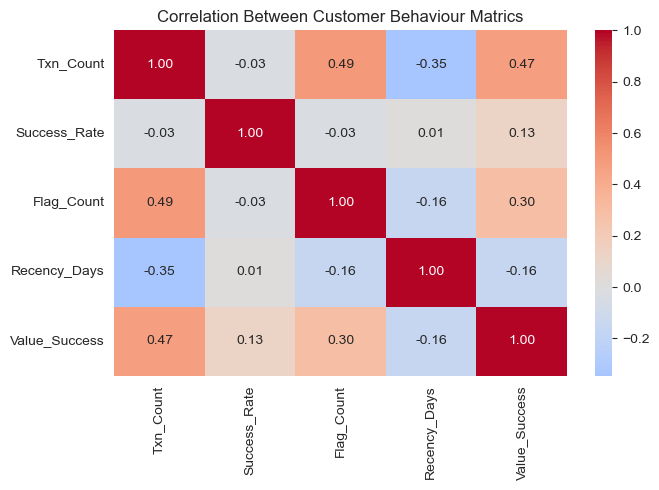

In [31]:
corr_cols = ["Txn_Count", "Success_Rate", "Flag_Count", "Recency_Days", "Value_Success"]
corr_matrix = cust_model[corr_cols].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Customer Behaviour Matrics")
plt.tight_layout()
plt.show()

**What it shows:** A correlation heatmap across transaction count, success rate, flag count, recency, and value. The strongest relationships: transaction count correlates with both value (+0.47) and flag count (+0.49); recency days correlates negatively with transaction count (−0.35, meaning more active customers have fewer days since their last transaction, as expected); success rate is essentially uncorrelated with everything else (max 0.13).


**Business Insight:** The +0.49 correlation between activity and flag count means your most active customers are also your most frequently flagged, which is expected (more transactions = more chances to be flagged) but worth stating explicitly, since it means the review team's workload scales directly with your best customers' activity, not with risky behaviour specifically. Meanwhile, success rate being uncorrelated with activity or value is reassuring: transaction failures aren't concentrated among your highest-value customers.

**Risk-Review Rate by Transaction Type and Channel**

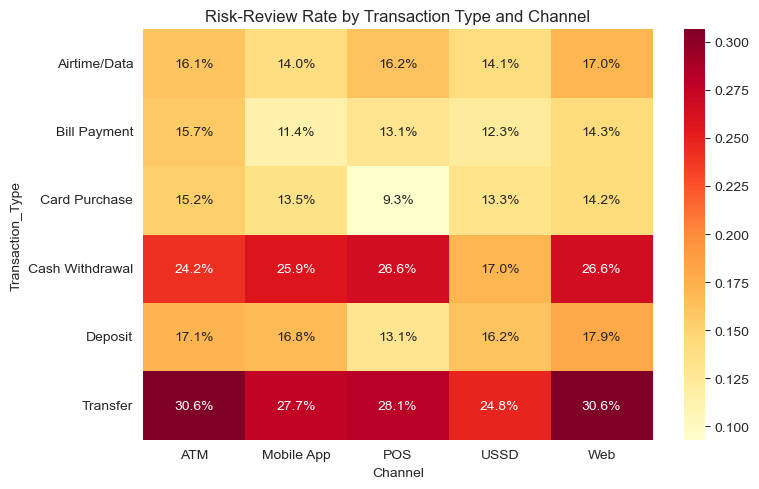

In [32]:
risk_pivot = Transaction.pivot_table(
    index="Transaction_Type", 
    columns="Channel",
    values="IsFlag",
    aggfunc="mean"
)

plt.figure(figsize=(8,5))
sns.heatmap(risk_pivot, annot=True, fmt=".1%", cmap="YlOrRd")
plt.title("Risk-Review Rate by Transaction Type and Channel")
plt.tight_layout()
plt.show()

**What it shows:** The same two-dimensional heatmap as the Excel Risk_Matrix, independently recomputed in Python. Transfer (24.8–30.6%) and Cash Withdrawal (17.0–26.6%) are highest-risk in every channel; Card Purchase is lowest, dropping as low as 9.3% on POS specifically.


**Business Insight:** Because this matrix was built twice, in two different tools, from the same raw data, and produced identical numbers, this is the most rigorously validated finding in the whole report — a strong candidate to lead with in your Part E validated findings.

**Customer Value Distribution - IQR outlier Detection**

Number of high-value outlier customers: 41


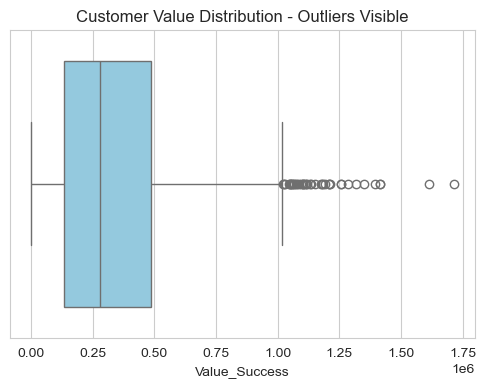

In [33]:
Q1 = cust_model["Value_Success"].quantile(0.25)
Q3 = cust_model["Value_Success"].quantile(0.75)
IQR = Q3 - Q1
cutoff = Q3 + 1.5 * IQR

outliers = cust_model[cust_model["Value_Success"] > cutoff]
print(f"Number of high-value outlier customers: {len(outliers)}")

plt.figure(figsize=(6,4))
sns.boxplot(x=cust_model["Value_Success"], color="skyblue")
plt.title("Customer Value Distribution - Outliers Visible")
plt.show()

**What it shows:** A boxplot of successful value per customer. The bulk of customers cluster between roughly ₦150,000 and ₦500,000 in value, with 41 customers sitting well above that range as statistical outliers, some reaching ₦1.5–1.75 million.


**Business Insight:** These 41 customers are exactly the kind of accounts a relationship-management or VIP programme should be built around. They're a small, identifiable list not an abstract "top decile", which makes them directly actionable.

**Monthly Volume and Value Trend**

     Month   Total_Value  Txn_Count  Flag_Count  MoM_Growth
0  2026-01  1.884894e+08       4133         766         NaN
1  2026-02  1.757869e+08       3734         757   -0.067391
2  2026-03  1.962010e+08       4133         829    0.116130


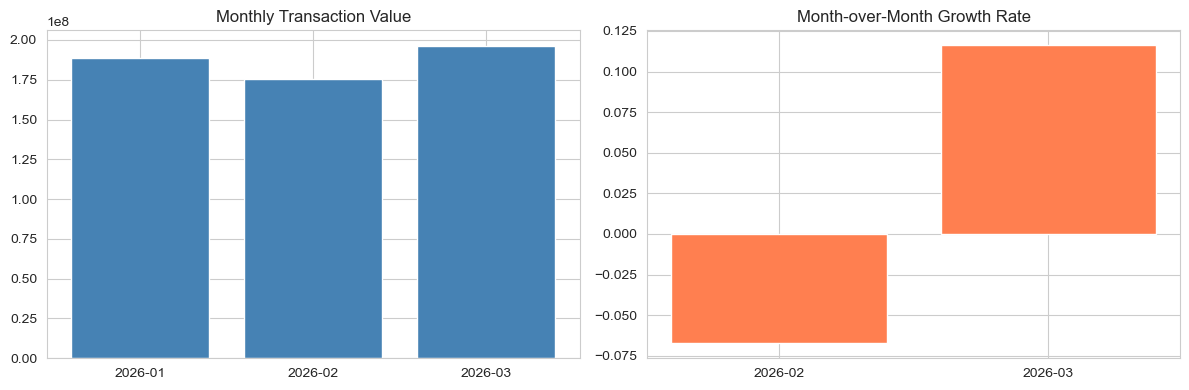

In [34]:
monthly = Transaction.groupby("Month").agg(
    Total_Value=("Amount_NGN", "sum"),
    Txn_Count=("Transaction_ID", "count"),
    Flag_Count=("IsFlag", "sum")
).reset_index()

monthly["MoM_Growth"] = monthly["Total_Value"].pct_change()
print(monthly)

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].bar(monthly["Month"].astype(str), monthly["Total_Value"], color="steelblue")
ax[0].set_title("Monthly Transaction Value")
ax[1].bar(monthly["Month"].astype(str), monthly["MoM_Growth"], color="coral")
ax[1].set_title("Month-over-Month Growth Rate")
plt.tight_layout()
plt.show()

**What it shows:** Transaction count and total value by month. Volume fell from 4,133 transactions in January to 3,734 in February (a 9.7% drop) before returning to 4,133 in March. Value followed a similar but less extreme pattern: −6.7% in February, +11.6% in March.

**Business Insight:** Volume and value moved together, which rules out one simple explanation — that February's dip was just a handful of very large transactions missing. The decline was broad-based across the month, which makes an operational or seasonal cause (fewer working days, a platform issue, etc.) more likely than a one-off data anomaly, and is worth investigating directly rather than assumed away.

In [35]:
sorted_vals = cust_model.sort_values("Value_Success", ascending=False).reset_index(drop=True)
sorted_vals["Cum_Pct"] = sorted_vals["Value_Success"].cumsum()/ sorted_vals["Value_Success"].sum()

n = len(sorted_vals)
top10_cut = int(n*0.10)
bottom50_cut = int(n*0.50)

top10_share = sorted_vals.loc[top10_cut - 1, "Cum_Pct"]
bottom50_share = 1 - sorted_vals.loc[bottom50_cut - 1, "Cum_Pct"]

print(f"Top 10% of customers generate {top10_share: .1%} of value")
print(f"Bottom 50% of customers generate {bottom50_share: .1%} of value")
print("Week 2 finding was: Top 10% = 25.9%, Bottom 50% = 21.2%")

Top 10% of customers generate  27.0% of value
Bottom 50% of customers generate  20.0% of value
Week 2 finding was: Top 10% = 25.9%, Bottom 50% = 21.2%
